<a href="https://colab.research.google.com/github/Navneetgupta440/pneumonia-detector1/blob/main/PneumoniaDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ✅ Cell 1: Install needed packages (use default TF)
!pip install -q tensorflow kaggle opencv-python matplotlib scikit-learn efficientnet

import tensorflow as tf, os
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ✅ Cell 2: Download dataset from Kaggle
from google.colab import files
files.upload()   # 👉 upload your kaggle.json file when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# download and unzip dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -q
!unzip -q chest-xray-pneumonia.zip -d /content/dataset


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other


In [5]:
# Verify dataset structure
!find /content/dataset/chest_xray -maxdepth 2 -type d


/content/dataset/chest_xray
/content/dataset/chest_xray/val
/content/dataset/chest_xray/val/PNEUMONIA
/content/dataset/chest_xray/val/NORMAL
/content/dataset/chest_xray/train
/content/dataset/chest_xray/train/PNEUMONIA
/content/dataset/chest_xray/train/NORMAL
/content/dataset/chest_xray/test
/content/dataset/chest_xray/test/PNEUMONIA
/content/dataset/chest_xray/test/NORMAL
/content/dataset/chest_xray/__MACOSX
/content/dataset/chest_xray/__MACOSX/chest_xray
/content/dataset/chest_xray/chest_xray
/content/dataset/chest_xray/chest_xray/val
/content/dataset/chest_xray/chest_xray/train
/content/dataset/chest_xray/chest_xray/test


In [6]:
# ✅ Cell 3: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create a folder to store models and outputs
!mkdir -p /content/drive/MyDrive/pneumonia_model
print("Drive mounted and folder created ✅")


Mounted at /content/drive
Drive mounted and folder created ✅


TRAIN → NORMAL: 1341, PNEUMONIA: 3875
VAL → NORMAL: 8, PNEUMONIA: 8
TEST → NORMAL: 234, PNEUMONIA: 390


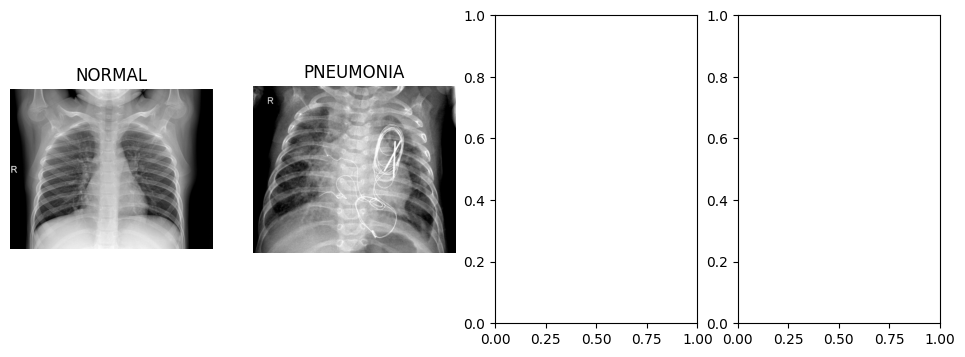

In [7]:
# ✅ Cell 4: Explore dataset
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_dir = "/content/dataset/chest_xray"
for subset in ['train', 'val', 'test']:
    normal = len(os.listdir(os.path.join(base_dir, subset, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(base_dir, subset, 'PNEUMONIA')))
    print(f"{subset.upper()} → NORMAL: {normal}, PNEUMONIA: {pneumonia}")

# show few sample images
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
categories = ['NORMAL', 'PNEUMONIA']
for i, category in enumerate(categories):
    img_path = os.path.join(base_dir, 'train', category, os.listdir(os.path.join(base_dir, 'train', category))[0])
    img = mpimg.imread(img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(category)
    axes[i].axis('off')
plt.show()


In [8]:
# ✅ Cell 5: Data loading and preprocessing
import tensorflow as tf
from tensorflow.keras import layers

# Set up constants
DATA_DIR = "/content/dataset/chest_xray"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training and validation datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

# Prefetching for better performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data augmentation layer
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
])

print("✅ Data pipeline ready — training and validation datasets created.")


Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
✅ Data pipeline ready — training and validation datasets created.


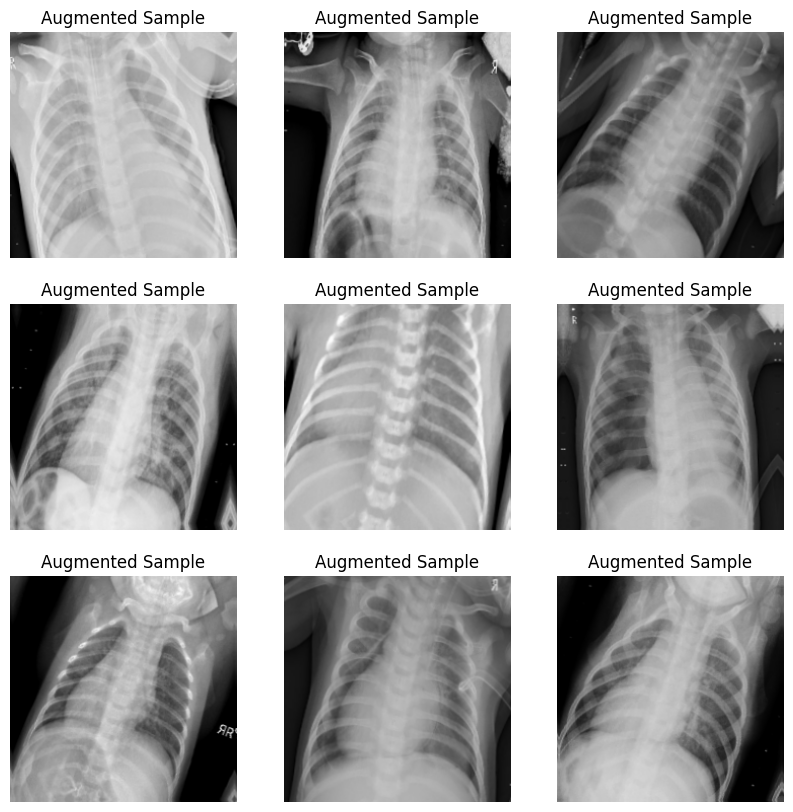

In [9]:
# ✅ Cell 6: Visualize augmentation effects
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        augmented_image = data_augmentation(images)[i]
        plt.subplot(3,3,i+1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.title("Augmented Sample")
        plt.axis("off")
    break
plt.show()


In [10]:
# ✅ Cell 7: Build and compile model
from tensorflow.keras import layers, models
import tensorflow as tf

# Load pretrained base model (EfficientNetB0)
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,      # exclude final classification layers
    weights='imagenet'      # use pretrained weights
)

# Freeze base model (we’ll unfreeze later for fine-tuning)
base_model.trainable = False

# Define model architecture
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)  # from previous step
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='AUC'), 'accuracy']
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
from tensorflow.keras import callbacks

# Save best model based on validation AUC
checkpoint_path = "/content/drive/MyDrive/pneumonia_model/best_model.h5"

ckpt = callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor='val_AUC',
    mode='max',
    save_best_only=True,
    verbose=1
)
early_stop = callbacks.EarlyStopping(monitor='val_AUC', patience=5, mode='max', restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_AUC', factor=0.5, patience=3, mode='max', verbose=1)

# Train (only top layers for now)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[ckpt, early_stop, reduce_lr]
)


Epoch 1/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - AUC: 0.7873 - accuracy: 0.7668 - loss: 0.4635
Epoch 1: val_AUC improved from -inf to 0.94531, saving model to /content/drive/MyDrive/pneumonia_model/best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 260ms/step - AUC: 0.7880 - accuracy: 0.7672 - loss: 0.4628 - val_AUC: 0.9453 - val_accuracy: 0.8750 - val_loss: 0.4330 - learning_rate: 0.0010
Epoch 2/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - AUC: 0.9600 - accuracy: 0.8984 - loss: 0.2401
Epoch 2: val_AUC improved from 0.94531 to 0.98438, saving model to /content/drive/MyDrive/pneumonia_model/best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - AUC: 0.9600 - accuracy: 0.8984 - loss: 0.2400 - val_AUC: 0.9844 - val_accuracy: 0.8750 - val_loss: 0.3458 - learning_rate: 0.0010
Epoch 3/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - AUC: 0.9671 - accuracy: 0.9121 - loss: 0.2085
Epoch 3: val_AUC improved from 0.98438 to 1.00000, saving model to /content/drive/MyDrive/pneumonia_model/best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - AUC: 0.9671 - accuracy: 0.9122 - loss: 0.2084 - val_AUC: 1.0000 - val_accuracy: 0.8750 - val_loss: 0.3157 - learning_rate: 0.0010
Epoch 4/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - AUC: 0.9744 - accuracy: 0.9249 - loss: 0.1877
Epoch 4: val_AUC did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - AUC: 0.9744 - accuracy: 0.9249 - loss: 0.1877 - val_AUC: 1.0000 - val_accuracy: 0.8750 - val_loss: 0.2729 - learning_rate: 0.0010
Epoch 5/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - AUC: 0.9772 - accuracy: 0.9327 - loss: 0.1748
Epoch 5: val_AUC did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - AUC: 0.9772 - accuracy: 0.9327 - loss: 0.1747 - val_AUC: 1.0000 - val_accuracy: 0.8750 - val_loss: 0.2576 - learning_rate: 0.0010
Epoch 6/8
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - AUC: 0.9810 - accuracy: 0.9387 - loss: 0.1612
Epoch 6: val_AUC did not improve from 1.00000

Epoch 6: ReduceLROnPlateau reducing 

In [13]:
# ✅ Cell 9: Fine-tuning phase
# Unfreeze the base model (but keep earlier layers frozen to avoid overfitting)
base_model.trainable = True

# Optional: freeze most of the early layers (they capture general edges/shapes)
for layer in base_model.layers[:-40]:  # only fine-tune last 40 layers
    layer.trainable = False

# Re-compile with a very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='AUC'), 'accuracy']
)

# Train again
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[ckpt, early_stop, reduce_lr]
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - AUC: 0.9723 - accuracy: 0.9194 - loss: 0.2328
Epoch 1: val_AUC did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 111ms/step - AUC: 0.9723 - accuracy: 0.9194 - loss: 0.2328 - val_AUC: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.2868 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - AUC: 0.9762 - accuracy: 0.9326 - loss: 0.1921
Epoch 2: val_AUC did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - AUC: 0.9763 - accuracy: 0.9326 - loss: 0.1921 - val_AUC: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.2459 - learning_rate: 1.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - AUC: 0.9819 - accuracy: 0.9422 - loss: 0.1635
Epoch 3: val_AUC did not improve from 1.00000
163/163 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - AUC: 0.9819 - accuracy: 0.9422 - loss: 0.1635 - val_AUC: 1.0000 - val_accuracy: 0.9375 - val_loss: 0.2235 - learning_rate: 1.0000e-05
Epoch 4/10
163/163 ━━

In [46]:
# Load test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

# Prefetch for performance
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 624 files belonging to 2 classes.


In [47]:
# Evaluate on test set
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}, Test AUC: {results[1]:.4f}, Test Accuracy: {results[2]:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 160ms/step - AUC: 0.6189 - accuracy: 0.6966 - loss: 0.5444
Test Loss: 0.3606, Test AUC: 0.9227, Test Accuracy: 0.8269


In [48]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels and predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_prob = model.predict(test_ds).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
report = classification_report(y_true, y_pred, target_names=['Normal','Pneumonia'])
print("Classification Report:\n", report)


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step
Confusion Matrix:
 [[146  88]
 [ 20 370]]
Classification Report:
               precision    recall  f1-score   support

      Normal       0.88      0.62      0.73       234
   Pneumonia       0.81      0.95      0.87       390

    accuracy                           0.83       624
   macro avg       0.84      0.79      0.80       624
weighted avg       0.83      0.83      0.82       624



In [51]:
model_save_path = "/content/drive/MyDrive/pneumonia_model/final_model.keras"
model.save(model_save_path)
print(f"Model saved to {model_save_path}")


Model saved to /content/drive/MyDrive/pneumonia_model/final_model.keras


In [26]:
# ✅ Cell 14: Save final model
model.save("/content/drive/MyDrive/pneumonia_model/pneumonia_detector_final.keras")
print("✅ Model saved to Google Drive!")


✅ Model saved to Google Drive!


In [52]:
from tensorflow.keras.models import load_model

loaded_model = load_model(model_save_path)
print("Model loaded successfully ✅")


Model loaded successfully ✅


In [53]:
!pip install -q gradio


In [57]:
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_pneumonia(img: Image.Image):
    img = img.convert("RGB").resize(IMG_SIZE)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    pred_prob = model.predict(img_array)[0][0]
    return {"NORMAL": float(1 - pred_prob), "PNEUMONIA": float(pred_prob)}


In [58]:
# Gradio interface
iface = gr.Interface(
    fn=predict_pneumonia,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="Pneumonia Detection from Chest X-Rays",
    description="Upload a chest X-ray image to predict Normal or Pneumonia."
)


In [59]:
# Launch interface with public shareable link
iface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6395b268cc096cebdf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
